In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
%cd /content/drive/MyDrive/in-context-learning/src


/content/drive/MyDrive/in-context-learning/src


In [17]:
!pip install munch
# should change import imp to import importlib

In [18]:
from collections import OrderedDict
import re
import os

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch
from tqdm.notebook import tqdm

from eval import get_run_metrics, read_run_dir, get_model_from_run
from plot_utils import basic_plot, collect_results, relevant_model_names

%matplotlib inline
%load_ext autoreload
%autoreload 2

sns.set_theme('notebook', 'darkgrid')
palette = sns.color_palette('colorblind')

run_dir = "../models"

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [19]:
#run_id = "baseline"
run_id = "moe"
if run_id=="baseline":
  %cd /content/drive/MyDrive/in-context-learning/models/polynomial_regression/baseline/
if run_id=="moe":
  %cd /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/
import torch

#convert checkpoint to .pt file
checkpoint_path = "checkpoint_3000000.zip"
output_path = "model_0.pt"
out_put_dir="./"

ckpt = torch.load(checkpoint_path, map_location="cpu")

state_dict = ckpt["model_state_dict"]

torch.save(state_dict, output_path)

print("Exported state.pt successfully!")

#_ = get_run_metrics(out_put_dir,step=0) #rerun the evaluation

%cd /content/drive/MyDrive/in-context-learning/src

/content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe
Exported state.pt successfully!
/content/drive/MyDrive/in-context-learning/src


In [20]:
df = read_run_dir(run_dir)
df  # list all the runs in our run_dir

moe
baseline


,run_id,task,model,kwargs,num_tasks,num_examples,n_dims,n_layer,n_head,run_name
1,baseline,polynomial_regression,Transformer-small,,-1,-1,1,6,4,polynomial_regression/baseline
0,moe,polynomial_regression,polynomial_regression_toy,,-1,-1,1,6,4,polynomial_regression/moe


In [21]:
task = "polynomial_regression"
run_path = os.path.join(run_dir, task, run_id)

# Plot pre-computed metrics

polynomial_regression/moe moe
Munch({'model': Munch({'family': 'gpt2_var_moe', 'vocab_size': 1, 'glu_type': 'None', 'n_dims': 1, 'n_embd': 128, 'n_head': 4, 'n_layer': 6, 'n_positions': 81, 'top_k': 1, 'num_experts': 4}), 'out_dir': '../models/polynomial_regression/moe', 'test_run': True, 'training': Munch({'batch_size': 64, 'curriculum': Munch({'degree': Munch({'end': 11, 'inc': 2, 'interval': 2000, 'start': 1}), 'points': Munch({'end': 81, 'inc': 2, 'interval': 2000, 'start': 5})}), 'data': 'uniform', 'keep_every_steps': 100000, 'learning_rate': 0.0001, 'num_tasks': None, 'num_training_examples': None, 'resume_id': None, 'save_every_steps': 1000, 'task': 'polynomial_regression', 'task_kwargs': Munch({}), 'train_steps': 3002000}), 'wandb': Munch({'entity': 'quzhaorui22-university-of-chinese-of-academy-of-sciences', 'log_every_steps': 100, 'name': 'polynomial_regression_toy', 'notes': '', 'project': 'in-context-training'})})


100%|██████████| 8/8 [00:00<00:00, 81049.35it/s]


gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_head=4_experts=4
in gpt2: Transformer
OLS_driver=None
ChebyshevFitModel
NN_n=3_uniform
decision_tree_max_depth=4
gpt2_moe_embd=128_layer=6_h

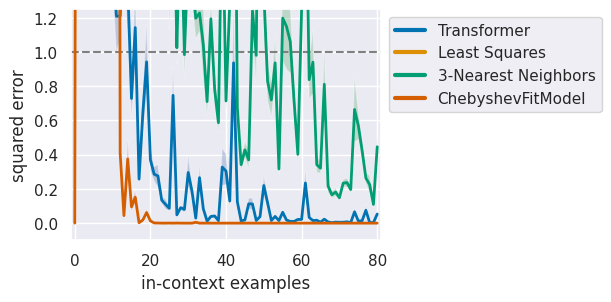

In [22]:
def valid_row(r):
    return r.task == task and r.run_id == run_id

start_x=0
if run_id=="moe":
  save_dir="/content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/"
if run_id=="baseline":
  save_dir="/content/drive/MyDrive/in-context-learning/models/polynomial_regression/baseline/plot/"

save_path=save_dir+"standard.jpg"
metrics = collect_results(run_dir, df, valid_row=valid_row,start_x=start_x)
_, conf = get_model_from_run(run_path, only_conf=True)
n_dims = conf.model.n_dims

models = relevant_model_names[task]
basic_plot(metrics["standard"], models=models,start_x=start_x,save_path=save_path)
plt.show()


Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/monomial_family_ood


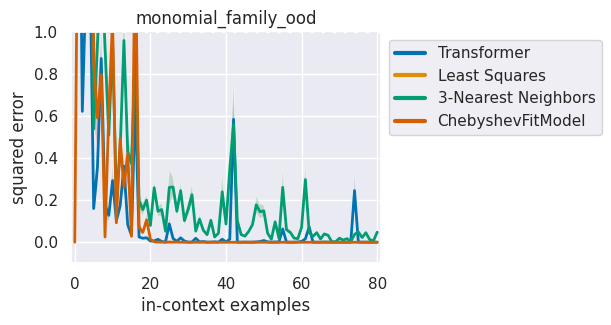

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/monomial_family_ood_noisy


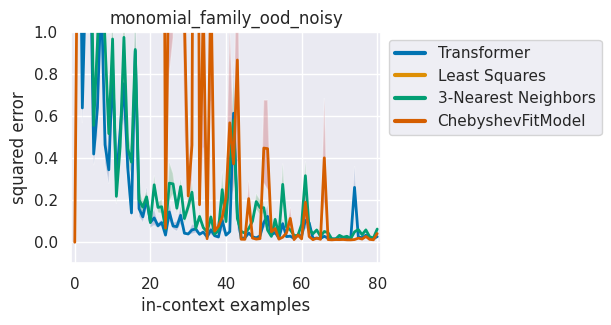

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/ood_deg12


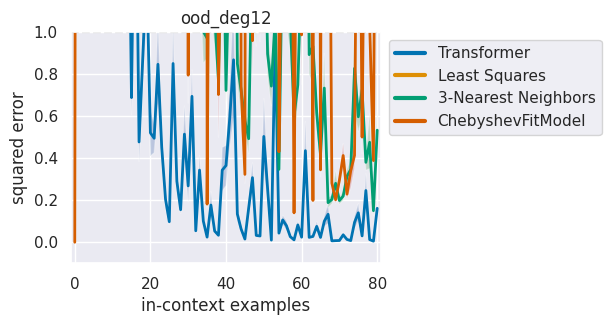

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/ood_deg13


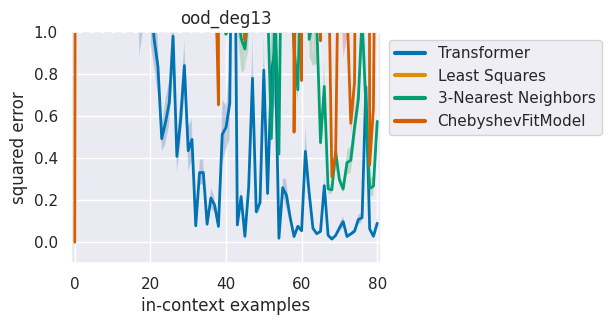

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/ood_deg14


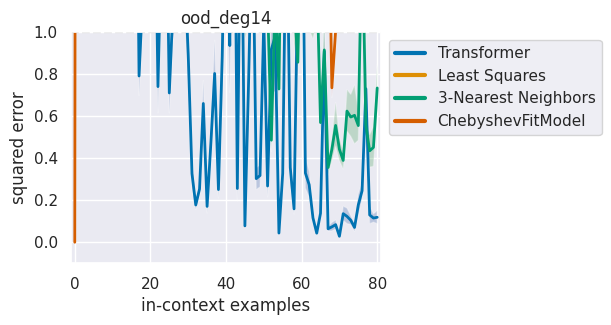

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/ood_deg15


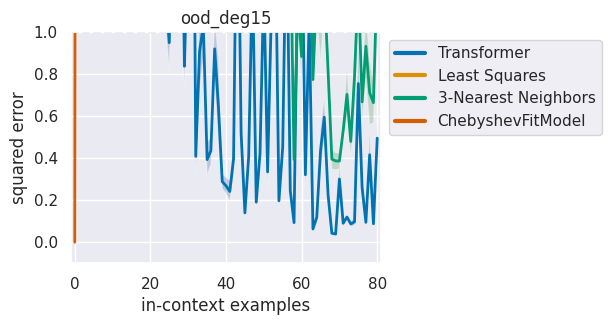

Saved figure to /content/drive/MyDrive/in-context-learning/models/polynomial_regression/moe/plot/standard_noisy


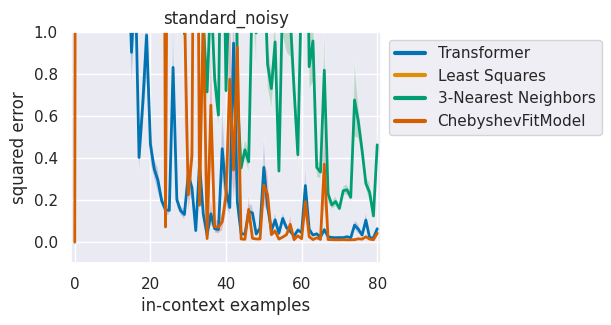

In [23]:
# plot any OOD metrics
for name, metric in metrics.items():
    if name == "standard": continue

    if "scale" in name:
        scale = float(name.split("=")[-1])**2
    else:
        scale = 1.0

    save_path=save_dir+f"{name}"
    trivial = 1.0 if "noisy" not in name else (1+1/n_dims)
    fig, ax = basic_plot(metric, models=models, trivial=trivial * scale,save_path=save_path)
    ax.set_title(name)

    if "ortho" in name:
        ax.set_xlim(-1, n_dims - 1)
    ax.set_ylim(-0.1* scale, 1 * scale)

    plt.show()

In [24]:
#used for training
!pip install pyyaml==6.0.1
!pip install quinine --no-deps
!pip install Cerberus==1.3.2


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 725.0/725.0 kB 35.5 MB/s eta 0:00:00
  Attempting uninstall: pyyaml
    Found existing installation: PyYAML 6.0.3
    Uninstalling PyYAML-6.0.3:
      Successfully uninstalled PyYAML-6.0.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.19.0 requires PyYAML<7.0.0,>=6.0.2, but you have pyyaml 6.0.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.5/52.5 kB 4.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for Cerberus: filename=Cerberus-1.3.2-py3-none-any.whl size=54354 sha256=f2de10f3f640872abd128b2ec64397cdb9e0c1552277413c998d9f6abf219cf7
  Stored in directory: /root/.cache/pip/wheels/be/9f/cf/6dcbfb905885c5b96a3422c7f1bb8e93e19ce87c8485a976b4
Successfully built Cerberus
ERROR: pip's dependency resolver does not currently take into account all the packag

In [25]:
!pip install cytoolz
!pip install funcy
!pip install toposort

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 86.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
quinine 0.3.0 requires funcy==1.15, which is not installed.
quinine 0.3.0 requires toposort==1.5, which is not installed.
quinine 0.3.0 requires cytoolz==0.11.0, but you have cytoolz 1.1.0 which is incompatible.
quinine 0.3.0 requires gin-config==0.3.0, but you have gin-config 0.5.0 which is incompatible.
quinine 0.3.0 requires munch==2.5.0, but you have munch 4.0.0 which is incompatible.
quinine 0.3.0 requires pyyaml==5.4, but you have pyyaml 6.0.1 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
quinine 0.3.0 requires toposort==1.5, which is not installed.
quinine 0.3.0 requires cytoolz==0.